In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import bte
import matplotlib as mpl
import seaborn as sns


Notebook to visualise Molnupiravir clusters with singletons from UShER phylogenies. Molnupiravir-like nodes are defined as nodes with LLRs > 3 and sum_contexts > 2.

In [2]:
df = pd.read_csv("/Users/reem/merged_bte_final.tsv", sep="\t")
df.head()

,node_id,parent_id,children,mutations,num_mutations,level,branch_length,subs,Counts,LLR,...,A>G_llr,CtoT_counts,C>T_llr,TtoC_counts,T>C_llr,sum_llrs,sum_contexts,country,date,num_descendants
0,Yunnan/0306-466/2020|EPI_ISL_429239|2020-03-06,node_1,[],['G15910T'],1,2,1.0,G>T,{'G>T': 1},-1.509730,...,0.0,Counter(),0.000000,Counter(),0.000000,-1.509730,0.000000,China,2020,1
1,Japan/DP0803/2020|EPI_ISL_416630|2020-02-17,node_1,[],['G4162T'],1,2,1.0,G>T,{'G>T': 1},-1.509730,...,0.0,Counter(),0.000000,Counter(),0.000000,-1.509730,0.000000,NaN,2020,1
2,node_2,node_1,['England/LEED-2A8B52/2020|EPI_ISL_539074|2020...,['T13090C'],1,2,1.0,T>C,{'T>C': 1},-0.528901,...,0.0,Counter(),0.000000,Counter({'A[T>C]G': 1}),-0.356234,-0.885135,-0.356234,England,2020,2
3,England/LEED-2A8B52/2020|EPI_ISL_539074|2020-0...,node_2,[],"['C1191T', 'C11674T']",2,3,2.0,"C>T,C>T",{'C>T': 2},0.872360,...,0.0,"Counter({'C[C>T]A': 1, 'A[C>T]T': 1})",-0.351044,Counter(),0.000000,0.521315,-0.351044,England,2020,1
4,England/SHEF-C06CE/2020|EPI_ISL_420245|2020-03-25,node_2,[],['T15821C'],1,3,1.0,T>C,{'T>C': 1},-0.528901,...,0.0,Counter(),0.000000,Counter({'A[T>C]G': 1}),-0.356234,-0.885135,-0.356234,England,2020,1


In [2]:
tree = bte.MATree(pb_file="/Users/reem/2026_updated_tree.pb")

Finished 'from_pb' in 115.5528 seconds


In [3]:
# GET NUMBER OF NODES IN THE TREE
all_nodes = list(tree.depth_first_expansion())
len(all_nodes)

21244182

In [13]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go


# Plot figure 1A and B
# Figure 1A : Number of molnupiravir nodes in both countries across the years using thresholds LLR>3 and context_llr>2
# Figure 1B: Number of sequenced genomes in Australia and France over the years
aus_df = df[df["country"] == "Australia"]
fra_df = df[df["country"] == "France"]
country_df = pd.concat([aus_df, fra_df], ignore_index=True)
years = [2020, 2021, 2022, 2023, 2024, 2025]

# Panel B- total genomes per year per country
rows = []
for year in years:
    df_yr = country_df[country_df["date"]==year]
    Mov_pred = (df_yr["LLR"] > 3) & (df_yr["sum_contexts"] > 2)
    rows.append({
        "year": year,
        "Australia_prop": Mov_pred[df_yr["country"]=="Australia"].sum()/len(df_yr[df_yr["country"]=="Australia"])*100,
        "France_prop": Mov_pred[df_yr["country"]=="France"].sum()/len(df_yr[df_yr["country"]=="France"])*100,
    })
prop_df = pd.DataFrame(rows)  


# Panel A - MOV nodes per year per country
aus_counts = aus_df["date"].value_counts().sort_index().reindex(years, fill_value=0)    
fra_counts = fra_df["date"].value_counts().sort_index().reindex(years, fill_value=0)


# Create subplots
fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.18)



# Add traces for panel A
fig.add_trace(go.Bar(x=prop_df["year"], y=prop_df["Australia_prop"], name="Australia", marker_color='#1f77b4', legendgroup="aus",showlegend=False), row=1, col=1)
fig.add_trace(go.Bar(x=prop_df["year"], y=prop_df["France_prop"], name="France", marker_color= '#ff7f0e', legendgroup="fra", showlegend=False), row=1, col=1)

# Add traces for panel B
fig.add_trace(go.Bar(x=years, y=aus_counts.values, name="Australia", marker_color='#1f77b4', legendgroup="aus"), row=1, col=2)
fig.add_trace(go.Bar(x=years, y=fra_counts.values, name="France", marker_color= '#ff7f0e', legendgroup="fra"), row=1, col=2)

width_in = 3.3
height_in = 1.6
dpi=300

# Update layout
fig.update_layout(
    width=int(width_in * dpi),    # Export at ACTUAL column width
    height=int(height_in * dpi),
    margin=dict(l=60, r=20, t=40, b=50),
    template='simple_white',
    legend=dict(
        font=dict(size=12),
        x=0.95,
        y=0.98,
        xanchor='left',
        yanchor='top',
        bgcolor='rgba(255, 255, 255, 0.9)',
        bordercolor='black',
        borderwidth=1
    )
)
fig.update_xaxes(title_text="Year", tickmode='linear', title_font=dict(size=20, color='black'), tickfont=dict(size=20, color='black'), linecolor='black', row=1, col=2)
fig.update_yaxes(title_text="Percentage of molnupiravir nodes", title_font=dict(size=20, color='black'), ticksuffix='%', tickfont=dict(size=20, color='black'), linecolor='black', row=1, col=2)

fig.update_xaxes(title_text="Year", tickmode='linear', title_font=dict(size=20, color='black'), tickfont=dict(size=20, color='black'), linecolor='black',row=1, col=1)
fig.update_yaxes(title_text="Number of genomes", title_font=dict(size=20, color='black'), tickfont=dict(size=20, color='black'), linecolor='black', row=1, col=1)


print(fig.layout.width, fig.layout.height)

# Add panel labels (A) and (B)
fig.add_annotation(
    text="<b>A</b>",
    xref="paper", yref="paper",
    x=-0.09, y=1.1,          # top-left corner of panel A; nudge x/y to taste
    showarrow=False,
    font=dict(size=22, color='black'),
    xanchor='left', yanchor='top'
)

fig.add_annotation(
    text="<b>B</b>",
    xref="paper", yref="paper",
    x=0.51, y=1.1,           # top-left corner of panel B; adjust based on your horizontal_spacing
    showarrow=False,
    font=dict(size=22, color='black'),
    xanchor='left', yanchor='top'
)
fig.show()
fig.write_image("/Users/reem/molnupiravir_paper/Figures/Figure1_Aus_Fra.pdf", width=width_in*dpi, height=height_in*dpi, scale=1) 


990 480


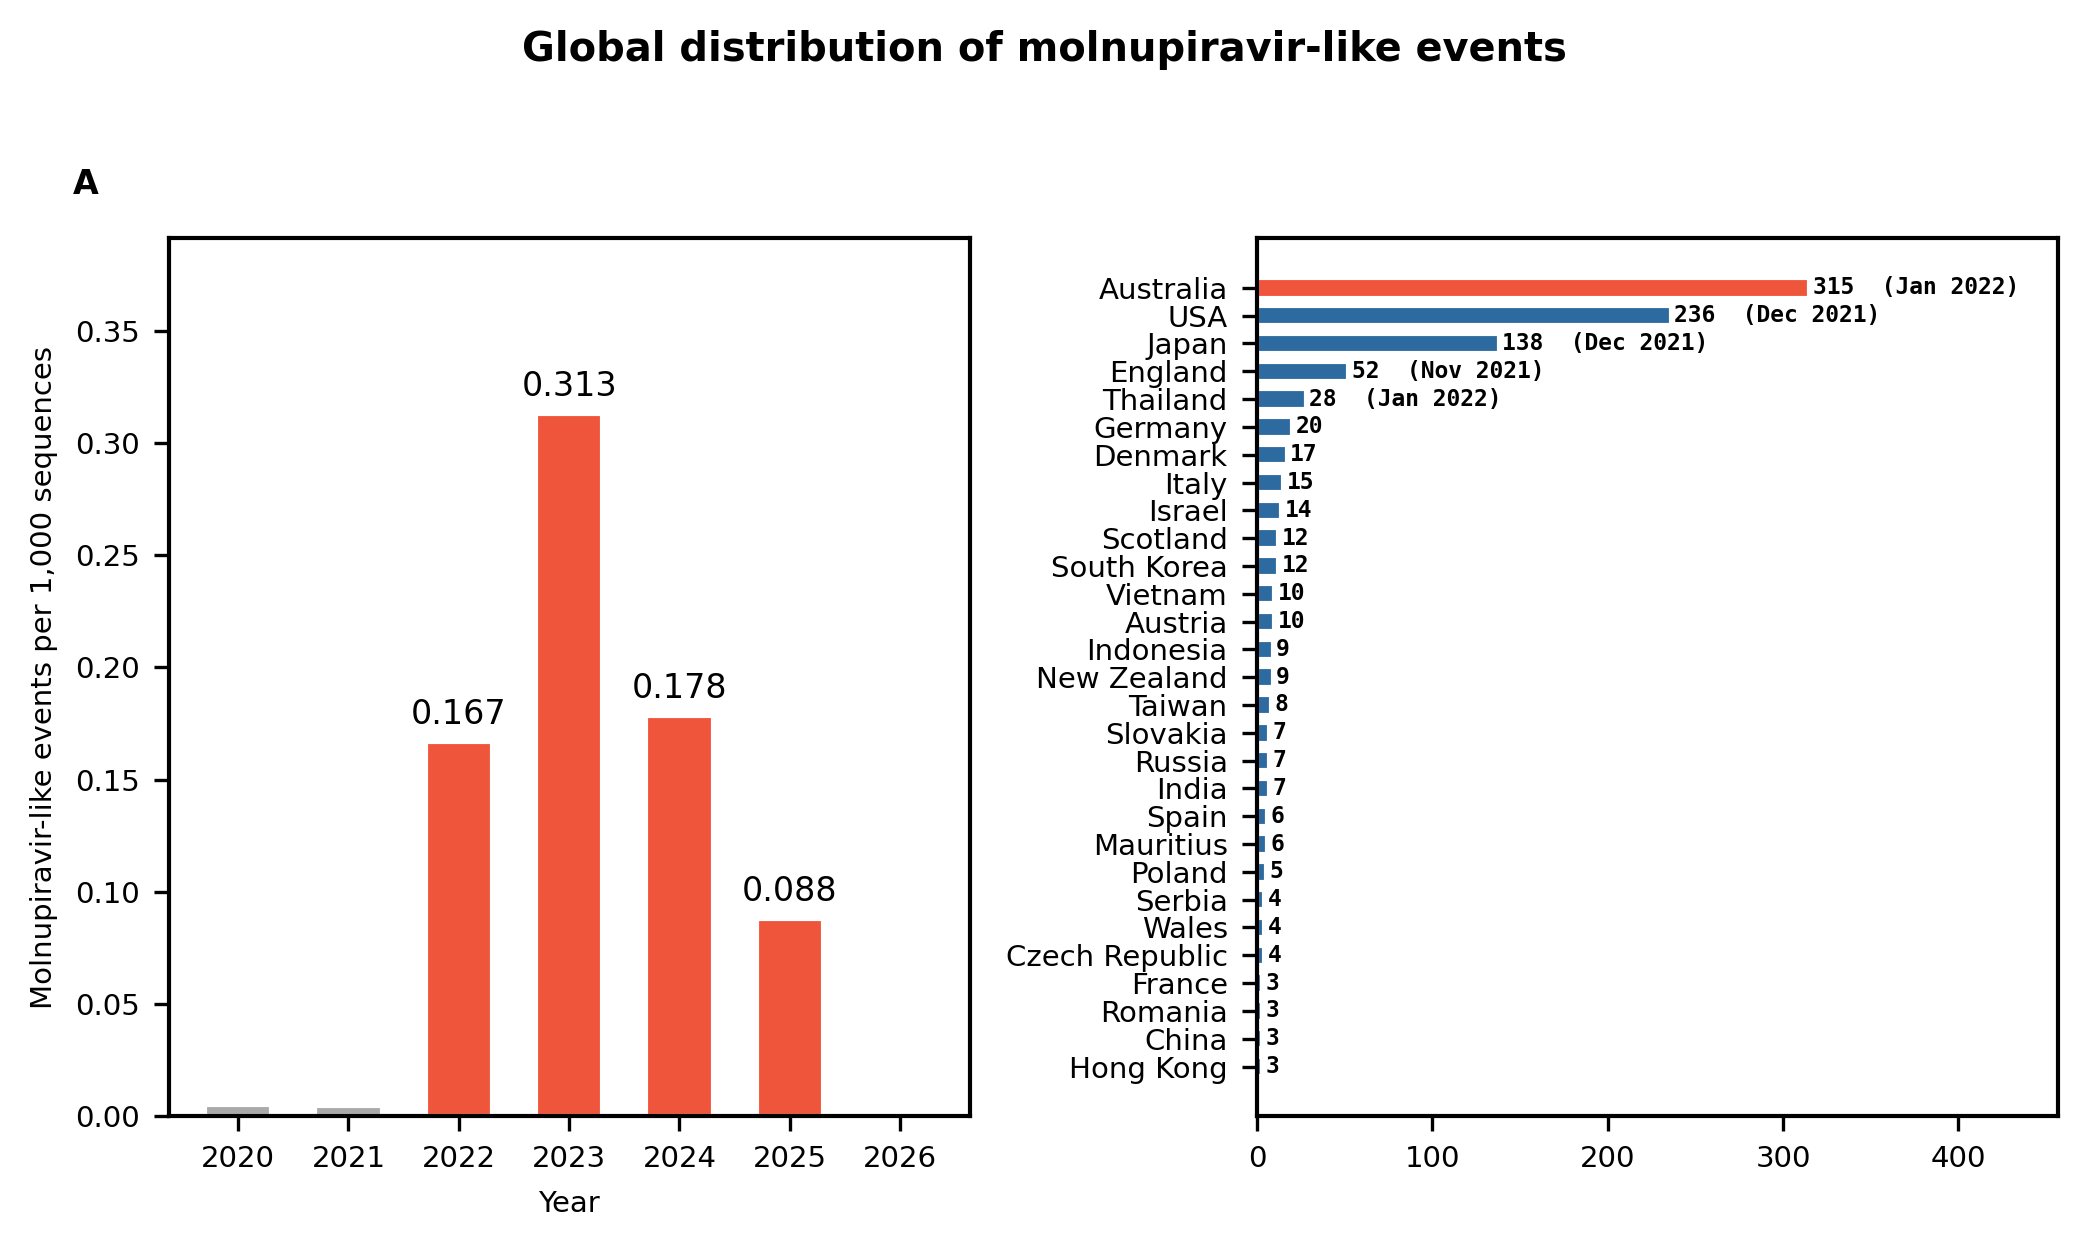

In [6]:
# Figure 3A - Molnupiravir events per 1000 sequences across the years
# Figure 3B - Geographical distribution of molnupiravir nodes

# ── Figure ────────────────────────────────────────────────

mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.labelcolor'] = 'black'
mpl.rcParams['xtick.color'] = 'black'
mpl.rcParams['ytick.color'] = 'black'
mpl.rcParams['axes.linewidth'] = 1
mpl.rcParams['xtick.labelsize'] = 7
mpl.rcParams['ytick.labelsize'] = 7
mpl.rcParams['axes.labelsize'] = 7

width_in = 7
height_in = 4
dpi=300

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(width_in, height_in), dpi=dpi)
fig.patch.set_facecolor('white')

df["is_mov"] = (df["LLR"] > 3) & (df["sum_contexts"] > 2)
df = df[~df["date"].isin([1905,1973,1993,0,2019])]  # Exclude irrelevant years


gisaid = pd.read_csv("/Users/reem/total_seqs_per_year.tsv", sep="\t").rename(columns={"count": "total_seqs"})

yearly = df.groupby("date")["is_mov"].sum().reset_index(name="mov_count").merge(gisaid, left_on="date", right_on="year").assign(mov_per_1000=lambda x: x["mov_count"] / x["total_seqs"] * 1000)
countries = pd.read_csv("/Users/reem/merged_bte_mov_strict.tsv", sep="\t")

# Excluding countries with <-= 2 clusters for better visualization
country_counts = countries["country"].str.strip()\
    .str.replace("SouthKorea", "South Korea")\
    .str.replace("NewZealand", "New Zealand")\
    .str.replace("CzechRepublic", "Czech Republic")\
    .value_counts().reset_index(name="n_clusters")\
    .query("n_clusters > 2")\
    .sort_values("n_clusters")

BLUE = "#2D6A9F"
RED  = "#EF553B"
GRAY = "#AAAAAA"



# Panel A
years = yearly["date"].astype(str)
colors_a = [GRAY if y in ["2020", "2021"] else RED for y in years]
bars = ax1.bar(years, yearly["mov_per_1000"], color=colors_a, edgecolor="white", width=0.6)

for bar, val in zip(bars, yearly["mov_per_1000"]):
    if val > 0.01:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.3f}", ha="center", va="bottom")

ax1.set(xlabel="Year", ylabel="Molnupiravir-like events per 1,000 sequences",
        ylim=(0, yearly["mov_per_1000"].max() * 1.25))
ax1.text(-0.12, 1.05, "A", transform=ax1.transAxes, fontweight="bold")

# Panel B
colors_b = [RED if c == "Australia" else BLUE for c in country_counts["country"]]
ax2.barh(country_counts["country"], country_counts["n_clusters"],
         color=colors_b, edgecolor="white", height=0.7)

# for i, val in enumerate(country_counts["n_clusters"]):
#     ax2.text(val + 2, i, str(int(val)), va="center")

# ax2.set(xlabel="Number of molnupiravir-like emergence events",
#         xlim=(0, country_counts["n_clusters"].max() * 1.12))
# ax2.legend(frameon=False, loc="lower right")
# ax2.text(-0.08, 1.05, "B", transform=ax2.transAxes, fontweight="bold")

# Add dates when mov started to countries
approval_dates = {
    'Australia': 'Jan 2022', 'USA': 'Dec 2021', 'Japan': 'Dec 2021',
    'England': 'Nov 2021', 'Thailand': 'Jan 2022'
}

countries = country_counts['country']  # Get the list of countries from the filtered DataFrame


for i, country in enumerate(country_counts["country"]):
    val = country_counts["n_clusters"].iloc[i]
    date = approval_dates.get(country, '')
    text = f"{val}" + (f"  ({date})" if date else "")
    ax2.set_xlim(0, country_counts["n_clusters"].max() * 1.45)
    ax2.text(val + 2, i, text, va="center", fontsize=5.5, fontweight="bold", color="black", fontfamily="monospace")
plt.suptitle("Global distribution of molnupiravir-like events", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/Users/reem/molnupiravir_paper/Figures/figure3_global_dist.pdf", format = "pdf", bbox_inches="tight")
plt.show()


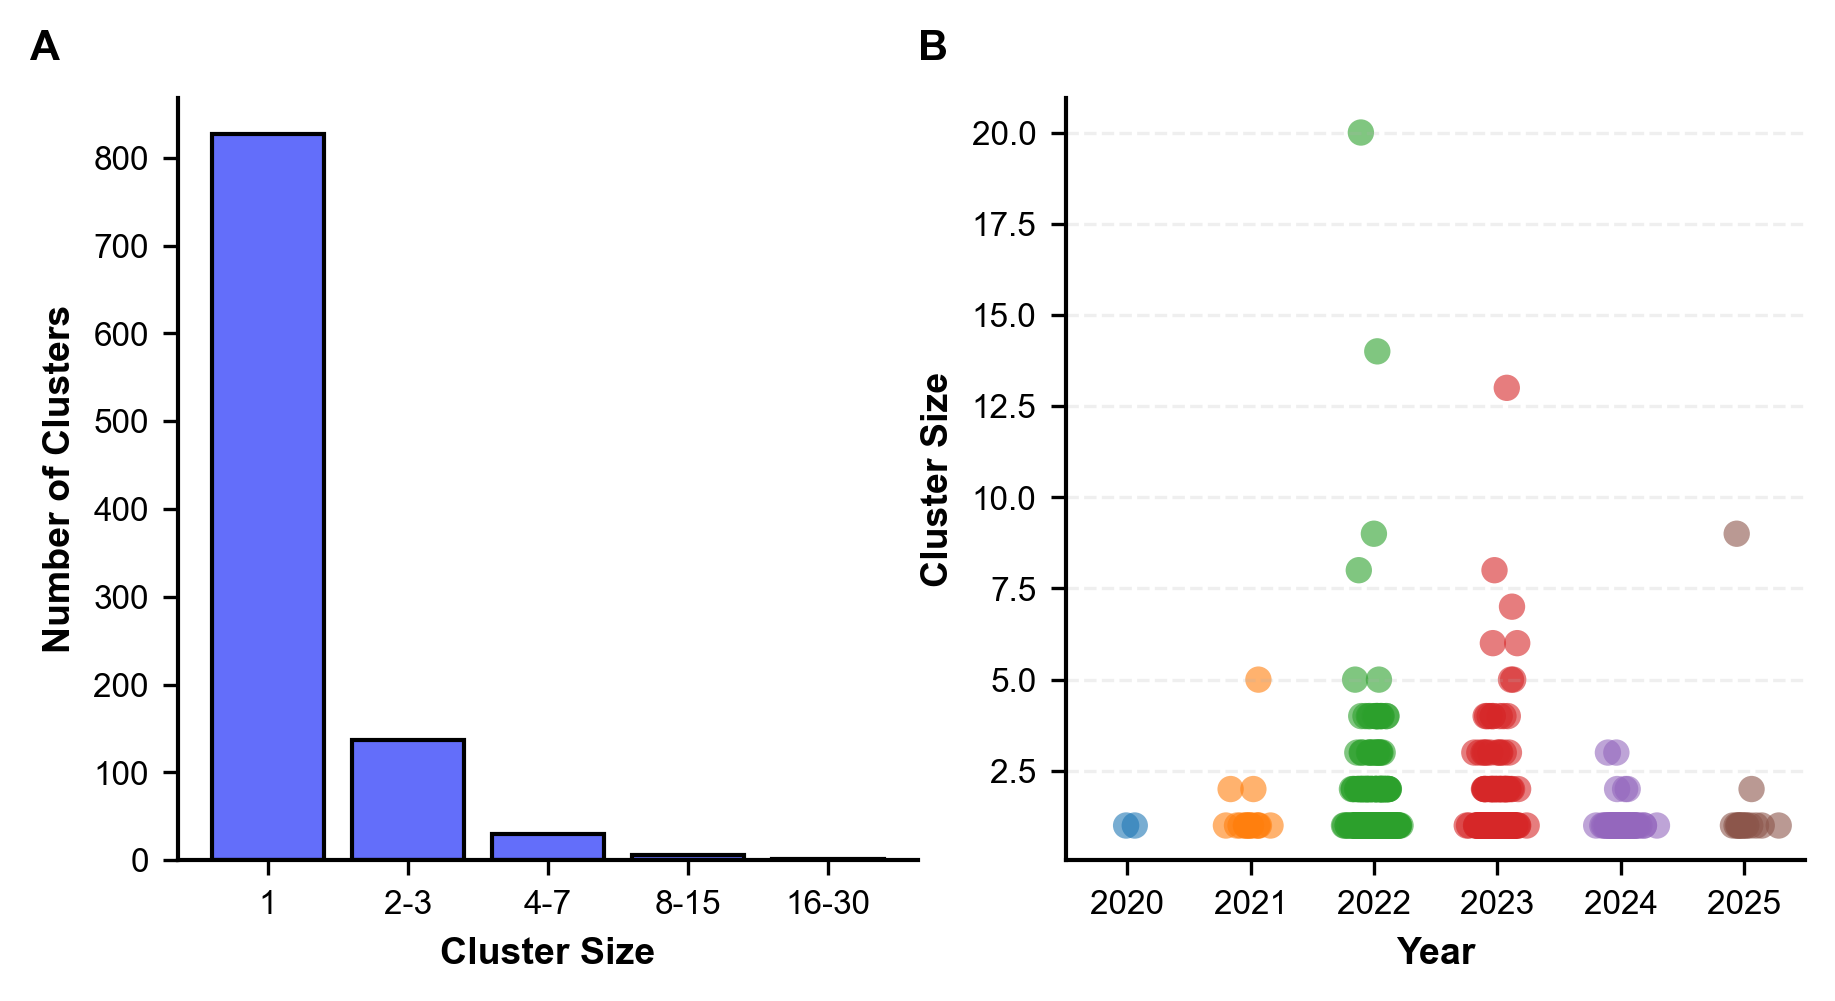

In [119]:
# Figure 4A - Cluster size distribution of molnupiravir nodes by number of descendants
# Figure 4B - temporal analysis of molnupiravir cluster sizes across the years

mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.labelcolor'] = 'black'
mpl.rcParams['xtick.color'] = 'black'
mpl.rcParams['ytick.color'] = 'black'
mpl.rcParams['axes.linewidth'] = 1
mpl.rcParams['xtick.labelsize'] = 8
mpl.rcParams['ytick.labelsize'] = 8
mpl.rcParams['axes.labelsize'] = 9

width_in = 7
height_in = 3.3
dpi=300

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(width_in, height_in), dpi=dpi)
fig.patch.set_facecolor('white')


# Panel A
bins = [1,2,4,8,16,32]
labels = ["1","2-3","4-7","8-15","16-30"]
df_mov = df[(df["LLR"] > 3) & (df["sum_contexts"] > 2)].copy()
df_mov["size_bin"] = pd.cut(df_mov["num_descendants"], bins=bins, right=False, labels=labels)

dist = df_mov.groupby("size_bin", observed=True).size().reset_index(name="n_clusters")

ax1.bar(dist["size_bin"], dist["n_clusters"], color='#636EFA', edgecolor='black', linewidth=1)
ax1.set_xlabel("Cluster Size", fontweight='bold')
ax1.set_ylabel("Number of Clusters",fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_facecolor('white')
ax1.text(-0.2, 1.05, 'A', transform=ax1.transAxes, fontweight='bold')

# ===== PANEL B: Scatter plot =====
# Extract year properly
df_mov["year"] = df_mov["date"].astype(int)

for year in sorted(df_mov['year'].dropna().unique()):
    year_data = df_mov[df_mov['year'] == year]
    x = year + np.random.normal(0, 0.08, len(year_data))
    y = year_data['num_descendants'].values
    ax2.scatter(x, y, alpha=0.6, s=40, edgecolors='none')

# FIX: Disable offset formatter and set proper x-axis
ax2.ticklabel_format(style='plain', axis='x')
ax2.set_xlim(2019.5, 2025.5)
ax2.set_xticks([2020, 2021, 2022, 2023, 2024, 2025])

ax2.set_xlabel("Year", fontweight='bold')
ax2.set_ylabel("Cluster Size", fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_facecolor('white')
ax2.grid(axis='y', alpha=0.2, linestyle='--')
ax2.text(-0.2, 1.05, 'B', transform=ax2.transAxes, fontweight='bold')

fig.savefig("/Users/reem/molnupiravir_paper/Figures/figure4_cluster_sizes.pdf", dpi=300, bbox_inches="tight", facecolor='white')

plt.show()



In [114]:
print(df_mov["year"].value_counts().sort_index())

year
1970    1001
Name: count, dtype: int64


In [6]:
dist

,size_bin,n_clusters
0,1,827
1,2-3,137
2,4-7,30
3,8-15,6
4,16-30,1


In [4]:
df_mov.to_csv("/Users/reem/mov_nodes_relaxed.tsv", index=False, sep = "\t")

In [2]:
# Get total seqs per country
df = pd.read_csv("/Users/reem/merged_bte_final.tsv", sep="\t")


In [ ]:
# Get total sequences per country from the main BTE dataframe

total_seqs_per_country = df["country"].str.strip().value_counts().reset_index()
total_seqs_per_country.columns = ["country", "total_seqs"]
total_seqs_per_country = total_seqs_per_country.sort_values("total_seqs", ascending=False)
# Exclude countries with <= 1000 sequences for better visualization
total_seqs_per_country = total_seqs_per_country[total_seqs_per_country["total_seqs"] > 1000]
print(total_seqs_per_country)

In [43]:
total_seqs_per_country.to_csv("/Users/reem/total_seqs_per_country.tsv", sep="\t", index=False)

In [47]:
# Get total sequences per year from the main BTE dataframe
total_seqs_per_year = df["date"].value_counts().reset_index()
total_seqs_per_year.columns = ["year", "total_seqs"]
total_seqs_per_year = total_seqs_per_year.sort_values("year")
print(total_seqs_per_year)

   year  total_seqs
4  2020      392149
0  2021     3512086
1  2022     3359968
2  2023     1051324
3  2024      437747
5  2025      182426
6  2026         793


In [48]:
total_seqs_per_year.to_csv("/Users/reem/total_seqs_per_year.tsv", sep="\t", index=False)

In [38]:
year_counts = df_mov["date"].value_counts().reset_index()
year_counts.columns = ["year", "num_mov_clusters"]
year_counts.sort_values(by="year", inplace=True)
fig = px.bar(
    year_counts.sort_values(by="year"),
    x="year", y="num_mov_clusters",
    title="Number of MOV clusters per year",
    color_discrete_sequence=["indianred"]
    
    )
fig.update_layout(xaxis_title="Year", yaxis_title="Number of MOV clusters")
fig.show()

In [39]:
fig.write_image("/Users/reem/new_figs/mov_clusters_per_year.svg")

In [ ]:
# Save value counts of years to a csv
year_counts.to_csv("/Users/reem/total_seqs_per_year.tsv",sep="\t", index=False)


In [30]:
year_counts = pd.read_csv("/Users/reem/total_seqs_per_year.tsv", sep="\t")

year_counts

,year,count
0,2019,50
1,2020,814241
2,2021,7341360
3,2022,6743816
4,2023,1549182
5,2024,580755
6,2025,213102
7,2026,1103


In [31]:
# Num Mov clusters per year
mov_counts_per_year = df["year"].value_counts().reset_index()
mov_counts_per_year.columns = ["year", "n_clusters"]
mov_counts_per_year.sort_values(by="year", inplace=True)
mov_counts_per_year

,year,n_clusters
5,2020,2
3,2021,16
0,2022,560
1,2023,329
2,2024,78
4,2025,16


In [33]:
plotly_df = pd.merge(year_counts, mov_counts_per_year, on="year", how="inner").fillna(0)
plotly_df

,year,count,n_clusters
0,2020,814241,2
1,2021,7341360,16
2,2022,6743816,560
3,2023,1549182,329
4,2024,580755,78
5,2025,213102,16


In [ ]:
# MOV_Clusters per year Normalized by total sequences per year
plotly_df["mov_normalized"] = (plotly_df["n_clusters"] / plotly_df["count"]) *1e6


fig = px.bar(
    plotly_df.sort_values(by="year"),
    x="year", y="mov_normalized",
    title="Number of MOV clusters normalized by total sequences per year",
    color_discrete_sequence=["indianred"]
    
    )
fig.update_layout(xaxis_title="Year", yaxis_title="Number of molnupiravir clusters per million sequences")
fig.show()

In [35]:
fig.write_image("/Users/reem/new_figs/mov_clusters_per_year_normalized.svg")

In [ ]:
# Mov Percentage per year

year_totals = mov_counts_per_year.merge(year_counts, on="year")

year_totals["mov_percentage"] = (year_totals["n_clusters"] / year_totals["count"]) * 100

year_totals


fig = px.bar(
    year_totals.sort_values(by="year"),
    x="year", y="mov_percentage",
    title="Percentage of molnupiravir clusters per year",
    color_discrete_sequence=["purple"]
    
    )
fig.update_layout(xaxis_title="Year", yaxis_title="Percentage of molnupiravir clusters (%)")
fig.write_image("/Users/reem/molnupiravir_paper/Figures/mov_clusters_per_year_percentage.pdf")
fig.show()


In [21]:
fig.write_image("/Users/reem/new_figs/percent_mov_clusters_per_year.svg")

In [46]:
# Functon to extract proportion of mov_seqs per country per year

def plot_mov_proportion(df, country):
    df_country = df[df["country"] == country]
    total_seqs = df_country["date"].value_counts().reset_index()
    mov_seqs = df_country[(df_country["LLR"]>3) & (df_country["sum_contexts"]>2)]["date"].value_counts().reset_index()
    #mov_seqs = df_country[df_country["sum_llrs"]>6]["date"].value_counts().reset_index()
    merged = total_seqs.merge(mov_seqs, on=total_seqs.columns[0], how="left").fillna(0)
    merged.columns = ["date", "total_seqs", "mov_seqs"]
    
    merged["proportion_mov"] = (merged["mov_seqs"] / merged["total_seqs"]) * 100
    merged = merged[merged["date"] != "0"].astype({"date": str})
    merged.drop(merged[(merged["date"] == "0") | (merged["date"] == "2020") | (merged["date"] == "2021") | (merged["date"] == "2026") | (merged["date"] == "1905")].index, inplace=True)
   
    fig = px.bar(merged.sort_values(by="date"),
        x="date", y="proportion_mov",
        title=f"Percentage of MOV sequences per year in {country}",
        color_discrete_sequence=["teal"]
    )
    fig.update_layout(xaxis_title="Year", yaxis_title="Percentage of MOV sequences (%)", font=dict(size=14))
    fig.update_yaxes(range=[0, 0.5])
    fig.show()
    fig.write_image(f"/Users/reem/new_figs/{country}_MOV_Proportion_per_Year.svg")
    return merged



plot_mov_proportion(df, country="Australia")      
#plot_mov_proportion(df, country="USA")

,date,total_seqs,mov_seqs,proportion_mov
0,2022,61506,187.0,0.304035
1,2023,27398,107.0,0.390539
3,2024,10305,20.0,0.194081
4,2025,7439,5.0,0.067213


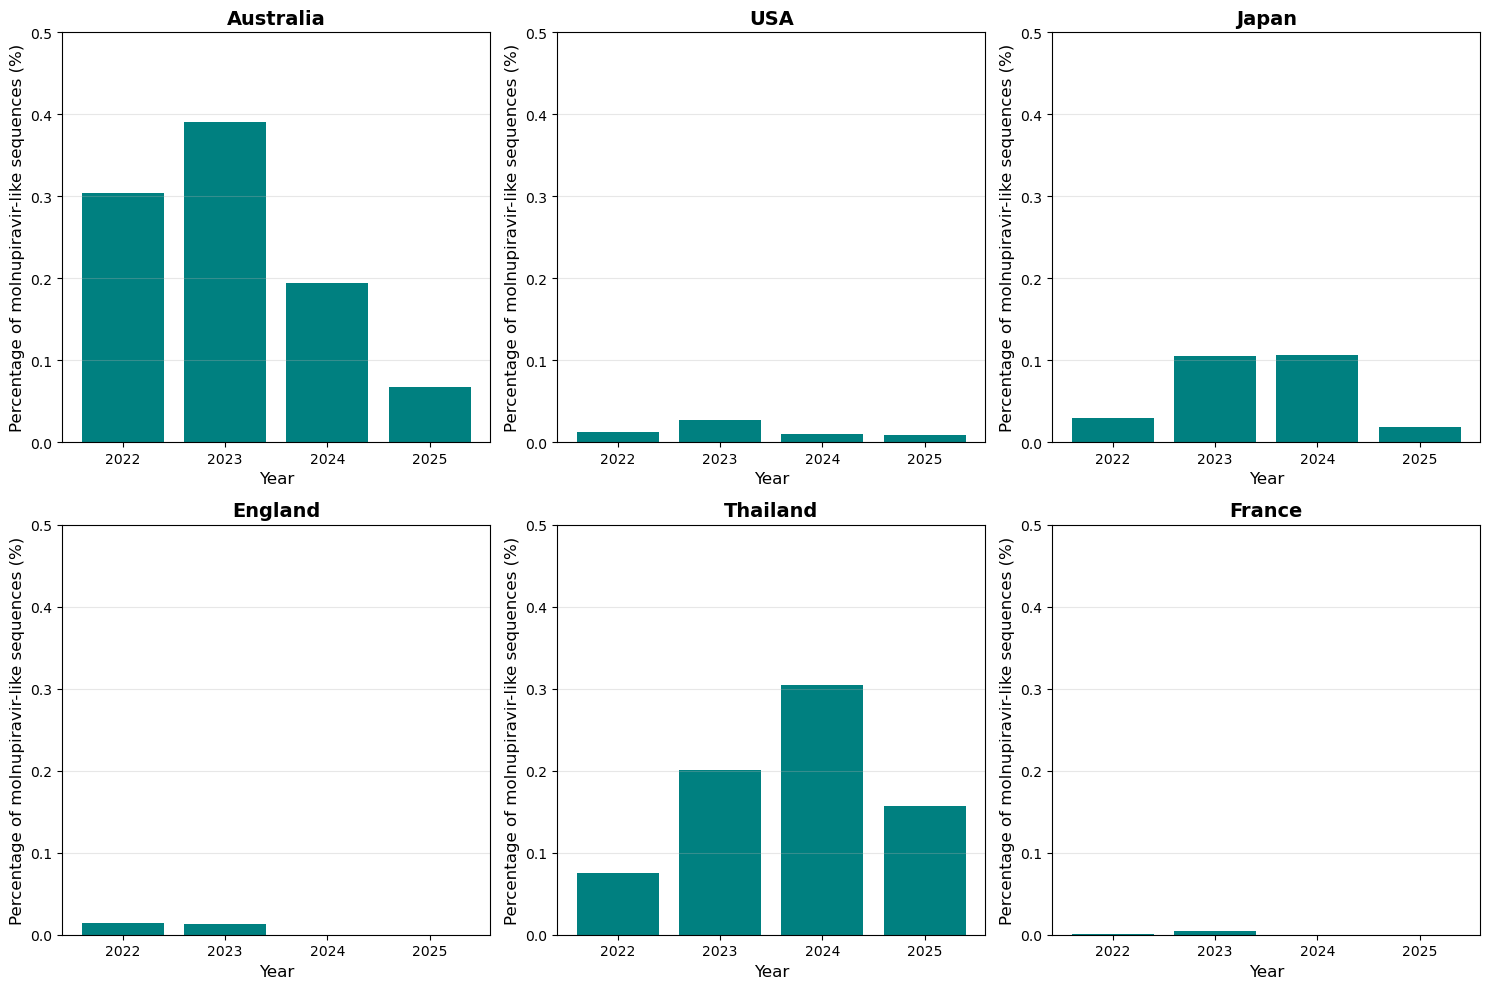

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_mov_proportion_matplotlib(df, countries):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()  # Flatten to 1D for easier iteration
    
    for idx, country in enumerate(countries):
        df_country = df[df["country"] == country]
        total_seqs = df_country["date"].value_counts().reset_index()
        mov_seqs = df_country[(df_country["LLR"] > 3) & (df_country["sum_contexts"] > 2)]["date"].value_counts().reset_index()
        
        merged = total_seqs.merge(mov_seqs, on=total_seqs.columns[0], how="left").fillna(0)
        merged.columns = ["date", "total_seqs", "mov_seqs"]
        
        merged["proportion_mov"] = (merged["mov_seqs"] / merged["total_seqs"]) * 100
        merged = merged[merged["date"] != "0"].astype({"date": str})
        merged.drop(merged[(merged["date"] == "0") | (merged["date"] == "2020") | (merged["date"] == "2021") | (merged["date"] == "2026") | (merged["date"] == "1905")].index, inplace=True)
        
        merged_sorted = merged.sort_values(by="date")
        
        axes[idx].bar(merged_sorted["date"], merged_sorted["proportion_mov"], color="teal")
        axes[idx].set_title(country, fontsize=14, fontweight="bold")
        axes[idx].set_xlabel("Year", fontsize=12)
        axes[idx].set_ylabel("Percentage of molnupiravir-like sequences (%)", fontsize=12)
        axes[idx].set_ylim([0, 0.5])
        axes[idx].grid(axis="y", alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("/Users/reem/molnupiravir_paper/Figures/mov_percentage_per_country.pdf", dpi=300, bbox_inches="tight")
    plt.show()

# Run it
countries = ["Australia", "USA", "Japan", "England", "Thailand", "France"]
plot_mov_proportion_matplotlib(df, countries)